# Quantum Preconditioning Analysis

Sections, in order: approximation ratio, PAR-based ε-hit bar charts, a combined
ε=0/ε=1% PAR line plot (presolve enabled vs disabled side by side), a
single-seed MIPSol trajectory plot, scaling across problem sizes, a
penalty-strategy comparison grid (Oracle upper-bound vs. cross-validated ρ
selection, presolve enabled vs disabled), and a performance-distribution plot
(final solution quality vs. the classical baseline, per QAOA depth). All
figures are for the QAOA (quantum) preconditioner family only — this notebook
does not analyze the classical-sweep preconditioner, which isn't part of the
accompanying paper.


In [1]:
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "qp_gurobi").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import qp_gurobi.utils as qutils
qutils = importlib.reload(qutils)

PlotConfig = qutils.PlotConfig
apply_plot_style = qutils.apply_plot_style
compute_hit_time_plot_limits = qutils.compute_hit_time_plot_limits
load_family_comparison_data = qutils.load_family_comparison_data
load_family_comparison_trajectory_data = qutils.load_family_comparison_trajectory_data
load_quantum_infinite_depth_comparison_data = qutils.load_quantum_infinite_depth_comparison_data
load_summary_data = qutils.load_summary_data
load_trajectory_data = qutils.load_trajectory_data
plot_hit_time_vs_penalty = qutils.plot_hit_time_vs_penalty
plot_hit_time_lines_side_by_side_presolve = qutils.plot_hit_time_lines_side_by_side_presolve
plot_mipsol_ratio_minus_one = qutils.plot_mipsol_ratio_minus_one
plot_layer_comparison_grid_by_presolve = qutils.plot_layer_comparison_grid_by_presolve
plot_layer_comparison_side_by_side_presolve = qutils.plot_layer_comparison_side_by_side_presolve
plot_ratio_minus_one = qutils.plot_ratio_minus_one
prepare_hit_time_metrics = qutils.prepare_hit_time_metrics
prepare_penalty_metrics = qutils.prepare_penalty_metrics
plot_performance_distribution = qutils.plot_performance_distribution

apply_plot_style()

N = 40          # problem size for quantum single-seed analysis
PRESOLVE = True
THRESHOLDS_TO_PLOT = [0.0, 0.001, 0.01]
LINE_EPS_THRESHOLDS = [0.0, 0.01]  # combined line plot only wants eps=0 and eps=1%
PENALTY_FILTER = None
TRAJ_PENALTY_FILTER = [round(x * 0.1, 3) for x in range(0, 13)]  # trajectory plots only: rho in [0.0, 1.2]
LOG_TIME_AXIS = True
PAR_FACTOR = 1.0
# Merged full-range sweeps + penalty-restricted (1.1-2.0) cluster runs; rebuild
# with scripts/merge_penalty_results.py whenever more cluster data lands.
RESULTS_DIR = REPO_ROOT / "results" / "merged"
TRAJ_SEED = 20
MIPSOL_VALUE_COL = "orig_obj"  # or "running_best_orig_obj"

# Approximation threshold for the scaling plot.
# 0.01 = find a solution within 1% of the baseline optimum.
EPS_THRESHOLD = 0.01

QUANTUM_LAYER = 1
QUANTUM_LAYERS = [1, 2, 3]
INCLUDE_P_INF = True

# N=8 is intentionally excluded: at this size the preconditioned instance's
# time-to-1%-optimal is anomalously large relative to N=12 (verified via raw
# Gurobi runtime_sec, not just the trajectory-derived hit time; baseline scales
# normally at N=8 so it isn't a hardware/overhead artifact). Most likely a
# small-N symmetry/degeneracy effect, not representative of the asymptotic
# scaling trend these plots are meant to show.
QUANTUM_SCALING_SIZES_ON  = [12, 16, 20, 24, 28, 32, 36, 40]
QUANTUM_SCALING_SIZES_OFF = [12, 16, 20, 24, 28, 32, 36, 40]

QUANTUM_SCALING_SIZES  = QUANTUM_SCALING_SIZES_ON  if PRESOLVE else QUANTUM_SCALING_SIZES_OFF
QUANTUM_COMPARE_PARAMS = QUANTUM_LAYERS + ([float("inf")] if INCLUDE_P_INF else [])

quantum_cfg = PlotConfig(n=N, family="quantum", layers=QUANTUM_LAYER)
presolve_label = "presolve enabled" if PRESOLVE else "presolve disabled"

print(f"Using {presolve_label}.")
print(f"Quantum setting: p={QUANTUM_LAYER}  (N={N})")
print(f"Include p=inf in quantum scaling comparison: {INCLUDE_P_INF}")
print(f"Scaling plot threshold: {EPS_THRESHOLD * 100:g}%-optimal")
utils_path = Path(qutils.__file__).resolve().relative_to(REPO_ROOT)
print(f"Loaded utils from: {utils_path}")


%load_ext autoreload
%autoreload 2

Using presolve enabled.
Quantum setting: p=1  (N=40)
Include p=inf in quantum scaling comparison: True
Scaling plot threshold: 1%-optimal
Loaded utils from: qp_gurobi/utils.py


## Quantum Penalty Analysis

For a single fixed problem size and QAOA depth (`N`, `QUANTUM_LAYER` above),
this section sweeps across every tested penalty ρ and answers two questions:

1. **`plot_ratio_minus_one`** — how does the preconditioned solution's
   objective compare to the classical baseline optimum at each ρ? A ratio of 0
   means the preconditioned solve found the exact same optimum as plain
   Gurobi; positive values mean it landed on a worse (higher-objective)
   solution.
2. **`plot_hit_time_vs_penalty`** — how long does it take to reach a solution
   within ε of the baseline optimum, as a function of ρ? Plotted at three ε
   thresholds (`THRESHOLDS_TO_PLOT`): exact match (ε=0), within 0.1%, and
   within 1%. Bars use PAR (Penalized Average Runtime) for instances that
   never reach the threshold — see the combined line plot below for the exact
   definition.


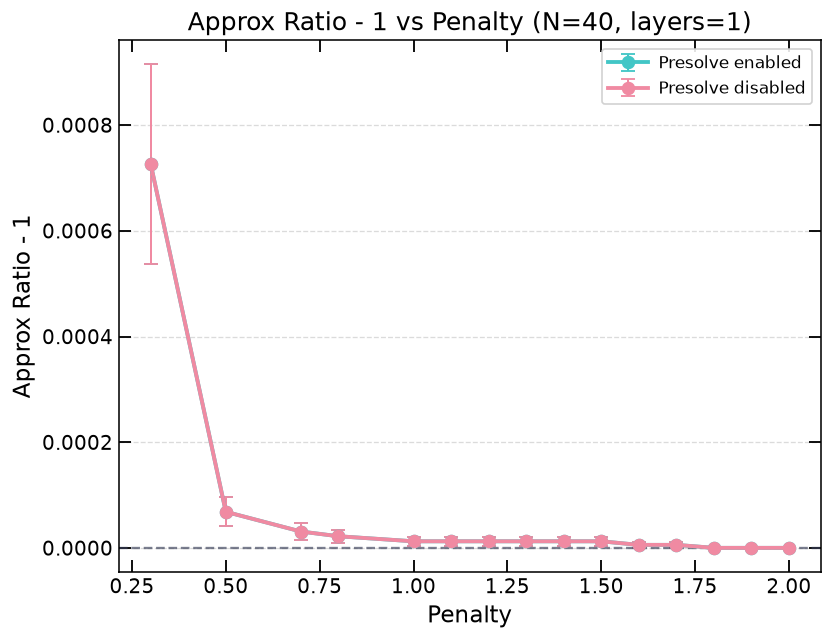

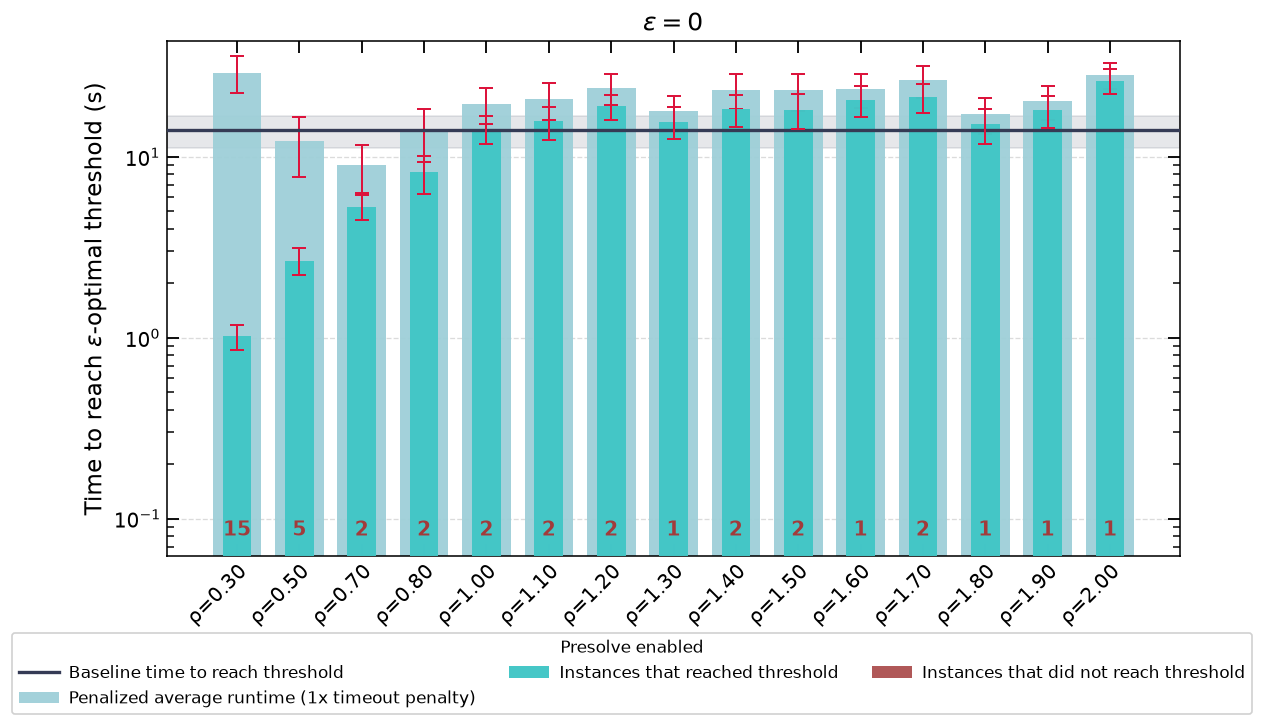

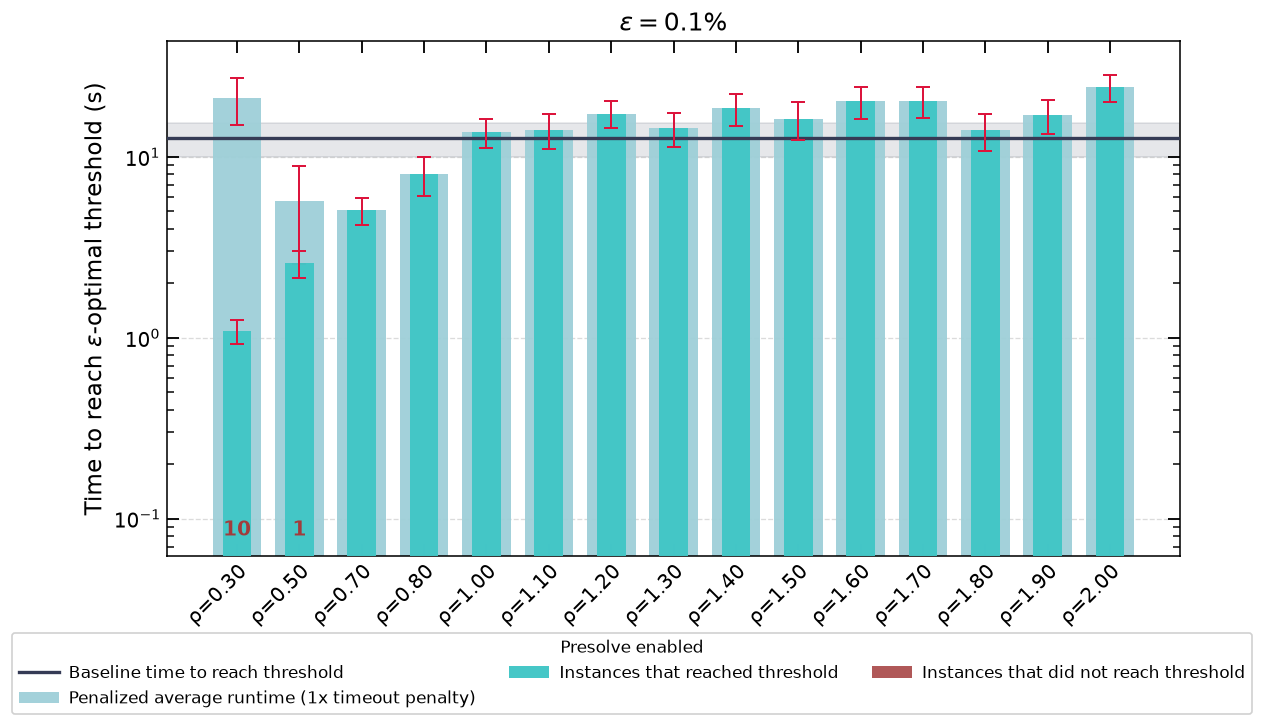

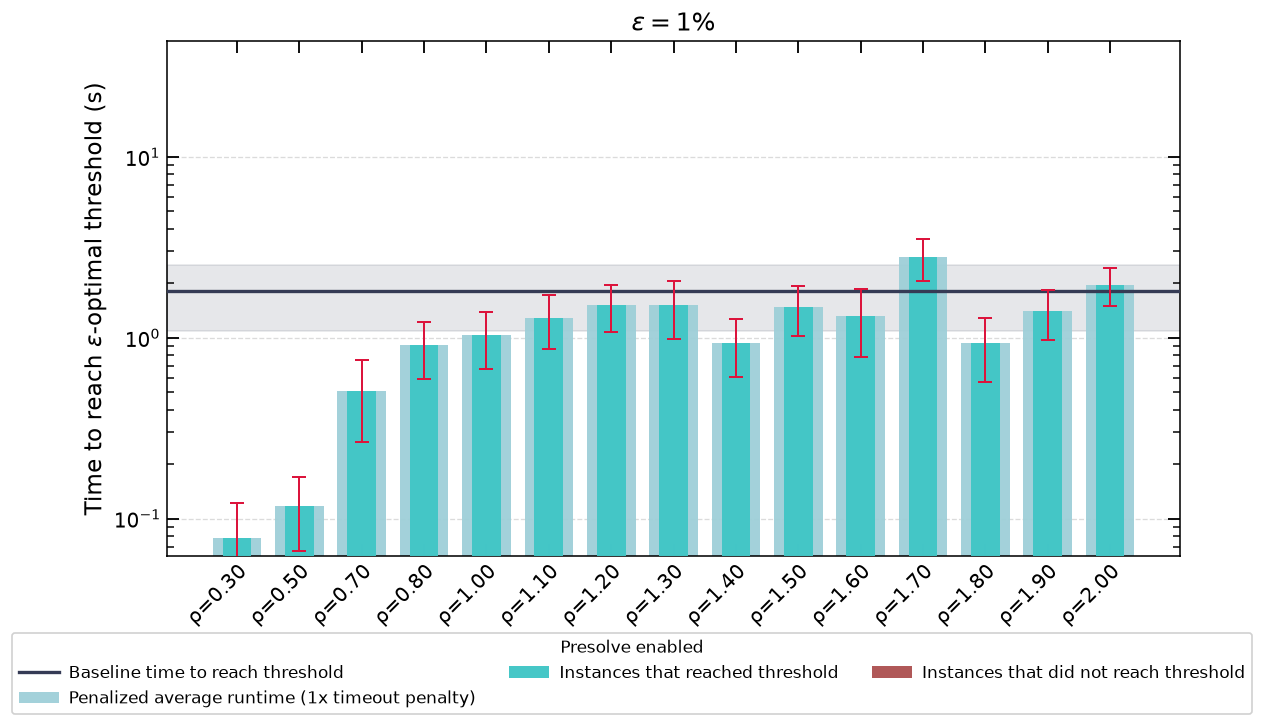

In [2]:
quantum_summary_df = load_summary_data(
    n=N,
    family="quantum",
    layers=QUANTUM_LAYER,
    results_dir=RESULTS_DIR,
)
quantum_traj_by_presolve = load_trajectory_data(
    n=N,
    family="quantum",
    layers=QUANTUM_LAYER,
    results_dir=RESULTS_DIR,
)
quantum_pre = prepare_penalty_metrics(quantum_summary_df)

plot_ratio_minus_one(quantum_pre, quantum_cfg)
plt.show()

quantum_hit_df = prepare_hit_time_metrics(
    quantum_summary_df,
    quantum_traj_by_presolve,
    quantum_cfg,
    THRESHOLDS_TO_PLOT,
    penalty_factor=PAR_FACTOR,
)
quantum_selected_hit_df = quantum_hit_df[quantum_hit_df["presolve"] == PRESOLVE].copy()
quantum_shared_y_limits = (
    compute_hit_time_plot_limits(
        quantum_selected_hit_df,
        presolve=PRESOLVE,
        thresholds=THRESHOLDS_TO_PLOT,
        penalty_filter=PENALTY_FILTER,
    )
    if LOG_TIME_AXIS
    else None
)

for threshold in THRESHOLDS_TO_PLOT:
    plot_hit_time_vs_penalty(
        quantum_selected_hit_df,
        quantum_cfg,
        presolve=PRESOLVE,
        thresholds=[threshold],
        penalty_filter=PENALTY_FILTER,
        y_log=LOG_TIME_AXIS,
        y_limits=quantum_shared_y_limits,
    )
    plt.show()


### PAR (Penalized Average Runtime) line view

Same underlying data as the bar charts above, but only ε=0 and ε=1%
(`LINE_EPS_THRESHOLDS`), redrawn as connected lines so the trend across ρ is
easier to follow, with presolve enabled (left) and disabled (right) side by
side on a shared, matched y-axis. For instances that never reach the
threshold within the recorded trajectory, the dashed **PAR** line substitutes
`own_runtime_sec + PAR_FACTOR × baseline_runtime_sec` in place of a hit-time
— a standard way to penalize non-convergence without just discarding the
instance. The dark-red numbers above the ε=0 markers show how many instances
(out of the total at that N) never converged, which is what's driving PAR
above the solid "reached" line at that point.


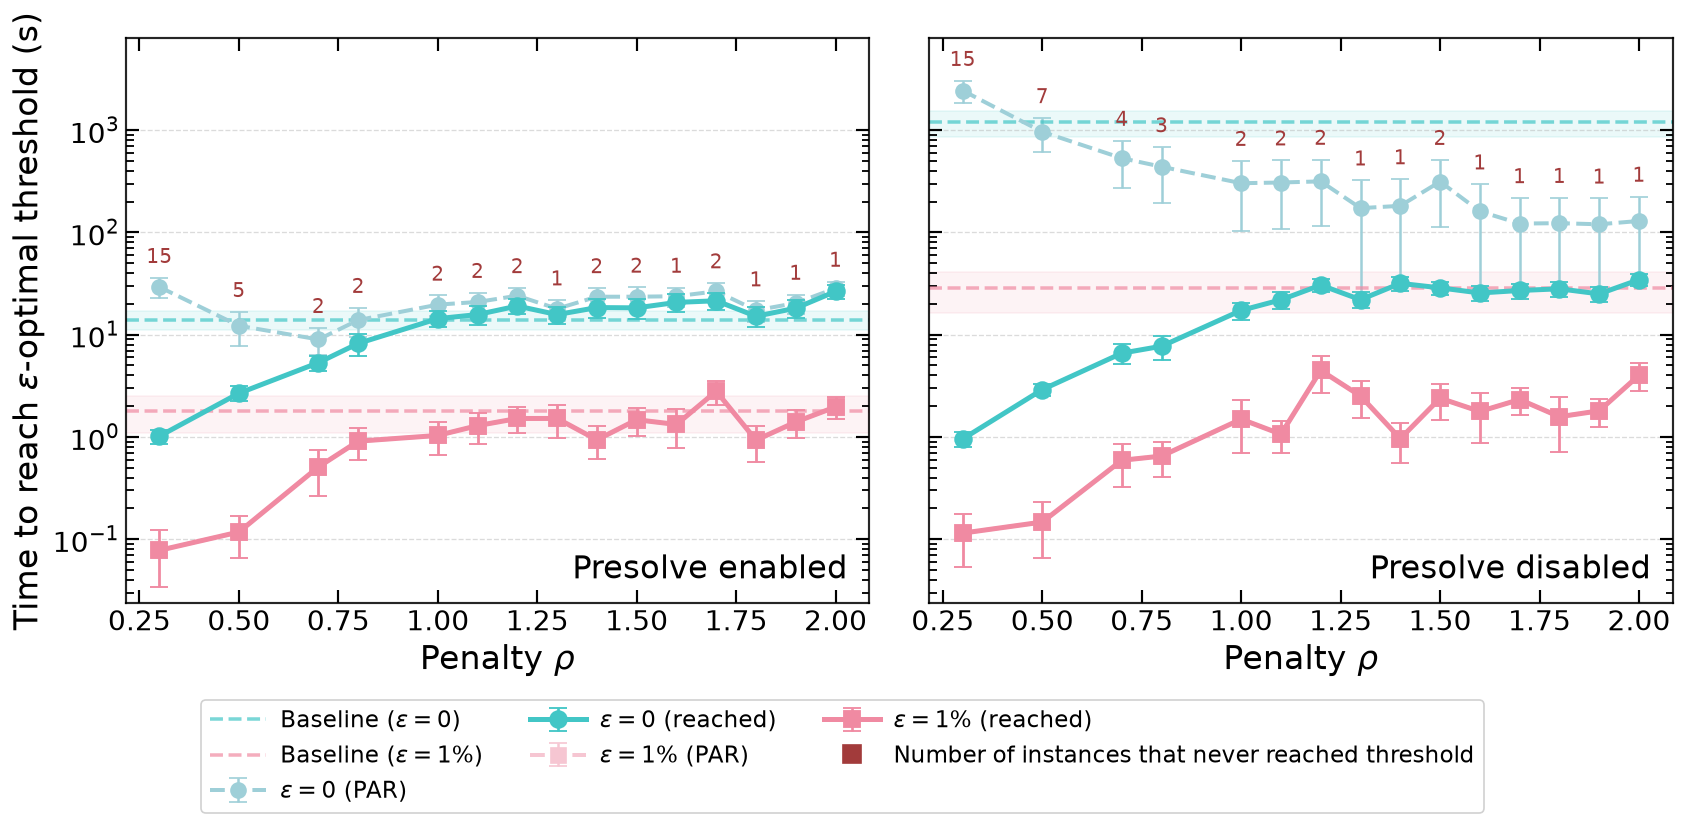

In [3]:
# Combined line-plot version of the bar charts above: both eps=0 and eps=1%
# on the same axes, presolve enabled (left) vs disabled (right) side by side.
fig_par_side = plot_hit_time_lines_side_by_side_presolve(
    quantum_hit_df,
    quantum_cfg,
    thresholds=LINE_EPS_THRESHOLDS,
    penalty_filter=PENALTY_FILTER,
    y_log=LOG_TIME_AXIS,
)
plt.show()

## Quantum Single-Seed MIPSol Trajectory

Zooms into one specific seed (`TRAJ_SEED`) and shows how Gurobi's incumbent
solution evolves during a *single* solve, one line per tested penalty
ρ (filtered to `TRAJ_PENALTY_FILTER`). The y-axis is the **original baseline
objective** evaluated at each improving incumbent, expressed as a ratio
relative to the true optimum — so you can watch individual solves converge (or
stall) in wall-clock time, rather than only seeing aggregated statistics
across seeds. Useful for sanity-checking that a ρ which looks bad in the
aggregate plots above isn't just one pathological seed, or vice versa.


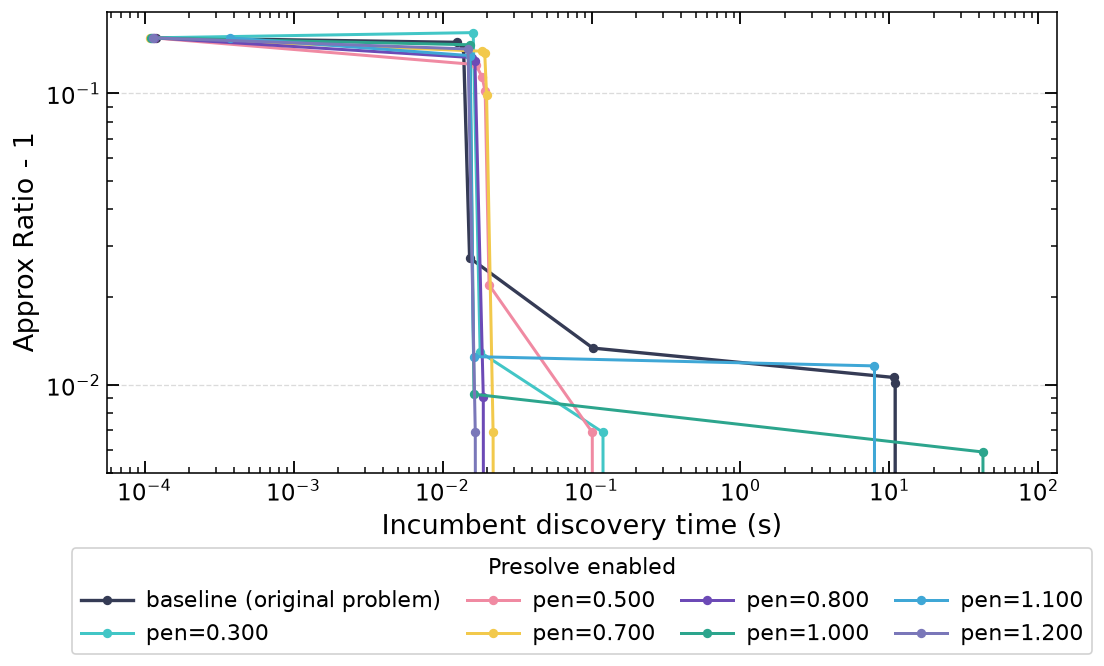

In [4]:
plot_mipsol_ratio_minus_one(
    traj_df=quantum_traj_by_presolve[PRESOLVE],
    cfg=quantum_cfg,
    presolve=PRESOLVE,
    mode="single",
    seed=TRAJ_SEED,
    penalty_filter=TRAJ_PENALTY_FILTER,
    value_col=MIPSOL_VALUE_COL,
)
plt.show()

## Quantum Scaling Across Problem Sizes

Moves from "one N, sweep ρ" to "sweep N, ρ fixed per depth" — the core
scaling result. For each QAOA depth p (and the classical baseline), a single ρ
is chosen once via the **`"fixed"` strategy**: the ρ that minimizes the mean
time-to-ε=1%-optimal, averaged evenly across every N (restricted to ρ values
that were actually tested at every N), then applied to all instances at every
N. This is deliberately *not* each instance's own best ρ — the point is to
simulate a practitioner who has to commit to one ρ in advance, not one who
gets to retune it per instance (that upper-bound comparison is the next
section). Presolve enabled (left) and disabled (right) are shown side by side
on a matched y-axis. Fitted lines are `O(base^n)` power laws; **N=8 is
excluded** (anomalously slow at this size, see the code comment above) and
**p=3 has no fitted line** here (only 5 problem sizes of data makes its
exponent too unstable to trust under this single-ρ strategy — its fit is
shown in the next section instead, where it's much better behaved).


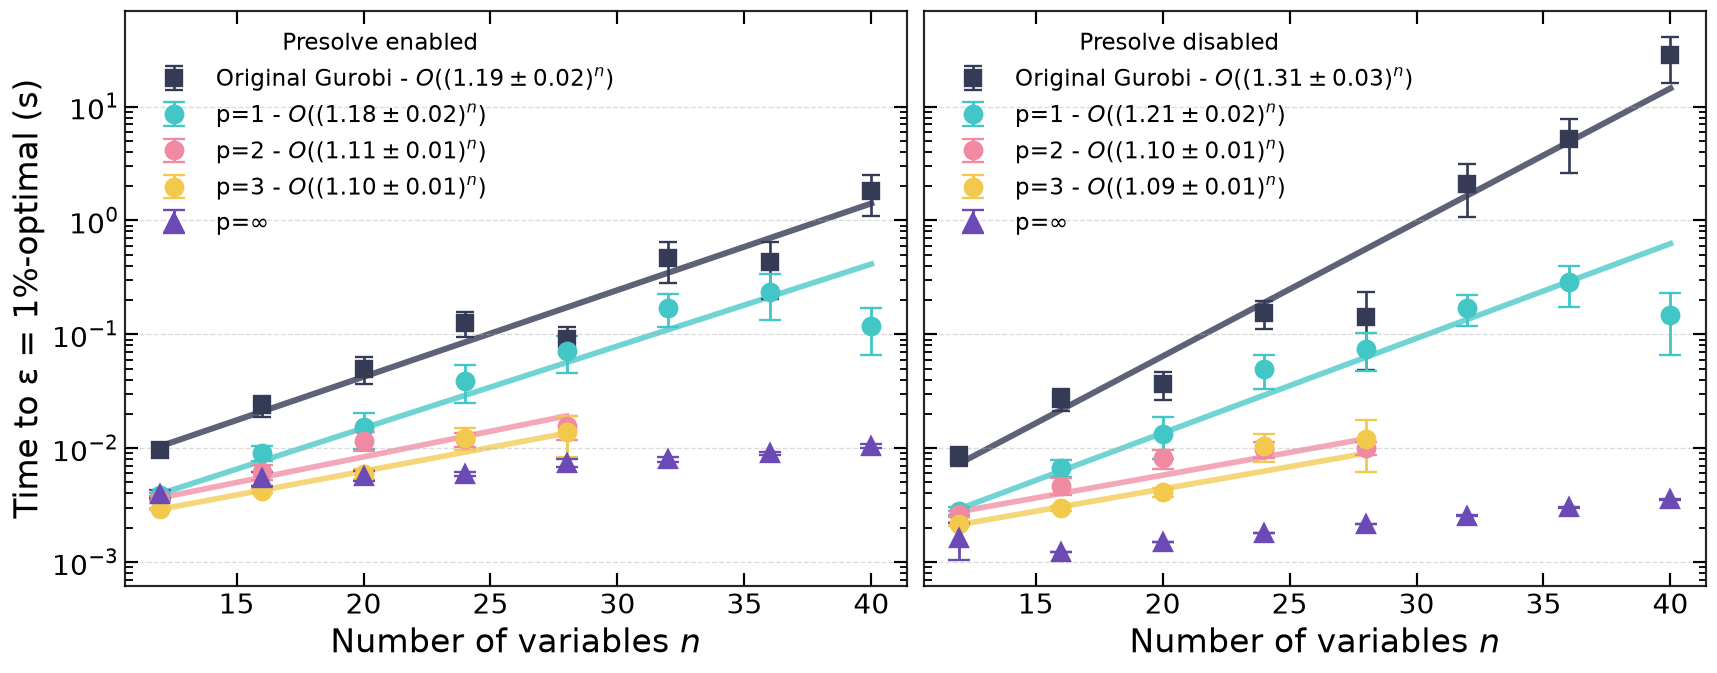

In [5]:
# Side-by-side quantum scaling: presolve enabled (left) vs disabled (right).
# Self-contained (loads its own on/off data) so it doesn't depend on the
# global PRESOLVE toggle.
quantum_side_on_df = load_family_comparison_data(
    problem_sizes=QUANTUM_SCALING_SIZES_ON,
    family="quantum",
    param_values=QUANTUM_LAYERS,
    presolve=True,
    results_dir=RESULTS_DIR,
)
quantum_side_on_traj_df = load_family_comparison_trajectory_data(
    problem_sizes=QUANTUM_SCALING_SIZES_ON,
    family="quantum",
    param_values=QUANTUM_COMPARE_PARAMS,
    presolve=True,
    results_dir=RESULTS_DIR,
)
quantum_side_off_df = load_family_comparison_data(
    problem_sizes=QUANTUM_SCALING_SIZES_OFF,
    family="quantum",
    param_values=QUANTUM_LAYERS,
    presolve=False,
    results_dir=RESULTS_DIR,
)
quantum_side_off_traj_df = load_family_comparison_trajectory_data(
    problem_sizes=QUANTUM_SCALING_SIZES_OFF,
    family="quantum",
    param_values=QUANTUM_COMPARE_PARAMS,
    presolve=False,
    results_dir=RESULTS_DIR,
)

if INCLUDE_P_INF:
    quantum_side_on_inf_df = load_quantum_infinite_depth_comparison_data(
        problem_sizes=QUANTUM_SCALING_SIZES_ON,
        presolve=True,
        results_dir=RESULTS_DIR,
        data_root=REPO_ROOT / "one_equality_new" / "complete_random",
    )
    quantum_side_off_inf_df = load_quantum_infinite_depth_comparison_data(
        problem_sizes=QUANTUM_SCALING_SIZES_OFF,
        presolve=False,
        results_dir=RESULTS_DIR,
        data_root=REPO_ROOT / "one_equality_new" / "complete_random",
    )
    quantum_side_on_df = pd.concat([quantum_side_on_df, quantum_side_on_inf_df], ignore_index=True)
    quantum_side_off_df = pd.concat([quantum_side_off_df, quantum_side_off_inf_df], ignore_index=True)

quantum_side_combined_df = pd.concat([quantum_side_on_df, quantum_side_off_df], ignore_index=True)
quantum_side_combined_traj_df = pd.concat([quantum_side_on_traj_df, quantum_side_off_traj_df], ignore_index=True)

fig_side = plot_layer_comparison_side_by_side_presolve(
    summary_df=quantum_side_combined_df,
    layers_list=QUANTUM_COMPARE_PARAMS,
    traj_df=quantum_side_combined_traj_df,
    eps_threshold=EPS_THRESHOLD,
    y_log=True,
    penalty_strategy="fixed",
)
plt.show()

## Quantum Scaling — Penalty Strategies (Oracle vs Cross-Validated)

Same scaling metric as above, but comparing two *more permissive* ways of
choosing ρ per instance instead of one fixed ρ for everyone:

- **Oracle** (left column): each instance uses its own retrospective best ρ
  — an upper bound on what's achievable, since it requires already knowing
  which ρ works best for that specific instance.
- **Cross-validated ρ** (right column): each seed's ρ is chosen from
  whichever value performed best on the *other* seeds at the same N (leave-
  one-out) — a more realistic, still-legitimate estimate of what a real
  calibration procedure could achieve.

Rows are presolve enabled (top) / disabled (bottom); within each row, both
columns share one y-axis (Oracle and Cross-validated are directly comparable
at a glance), while the two rows are independent of each other. The gap
between the Oracle and Cross-validated curves is a measure of how much
performance is lost by not having per-instance hindsight.


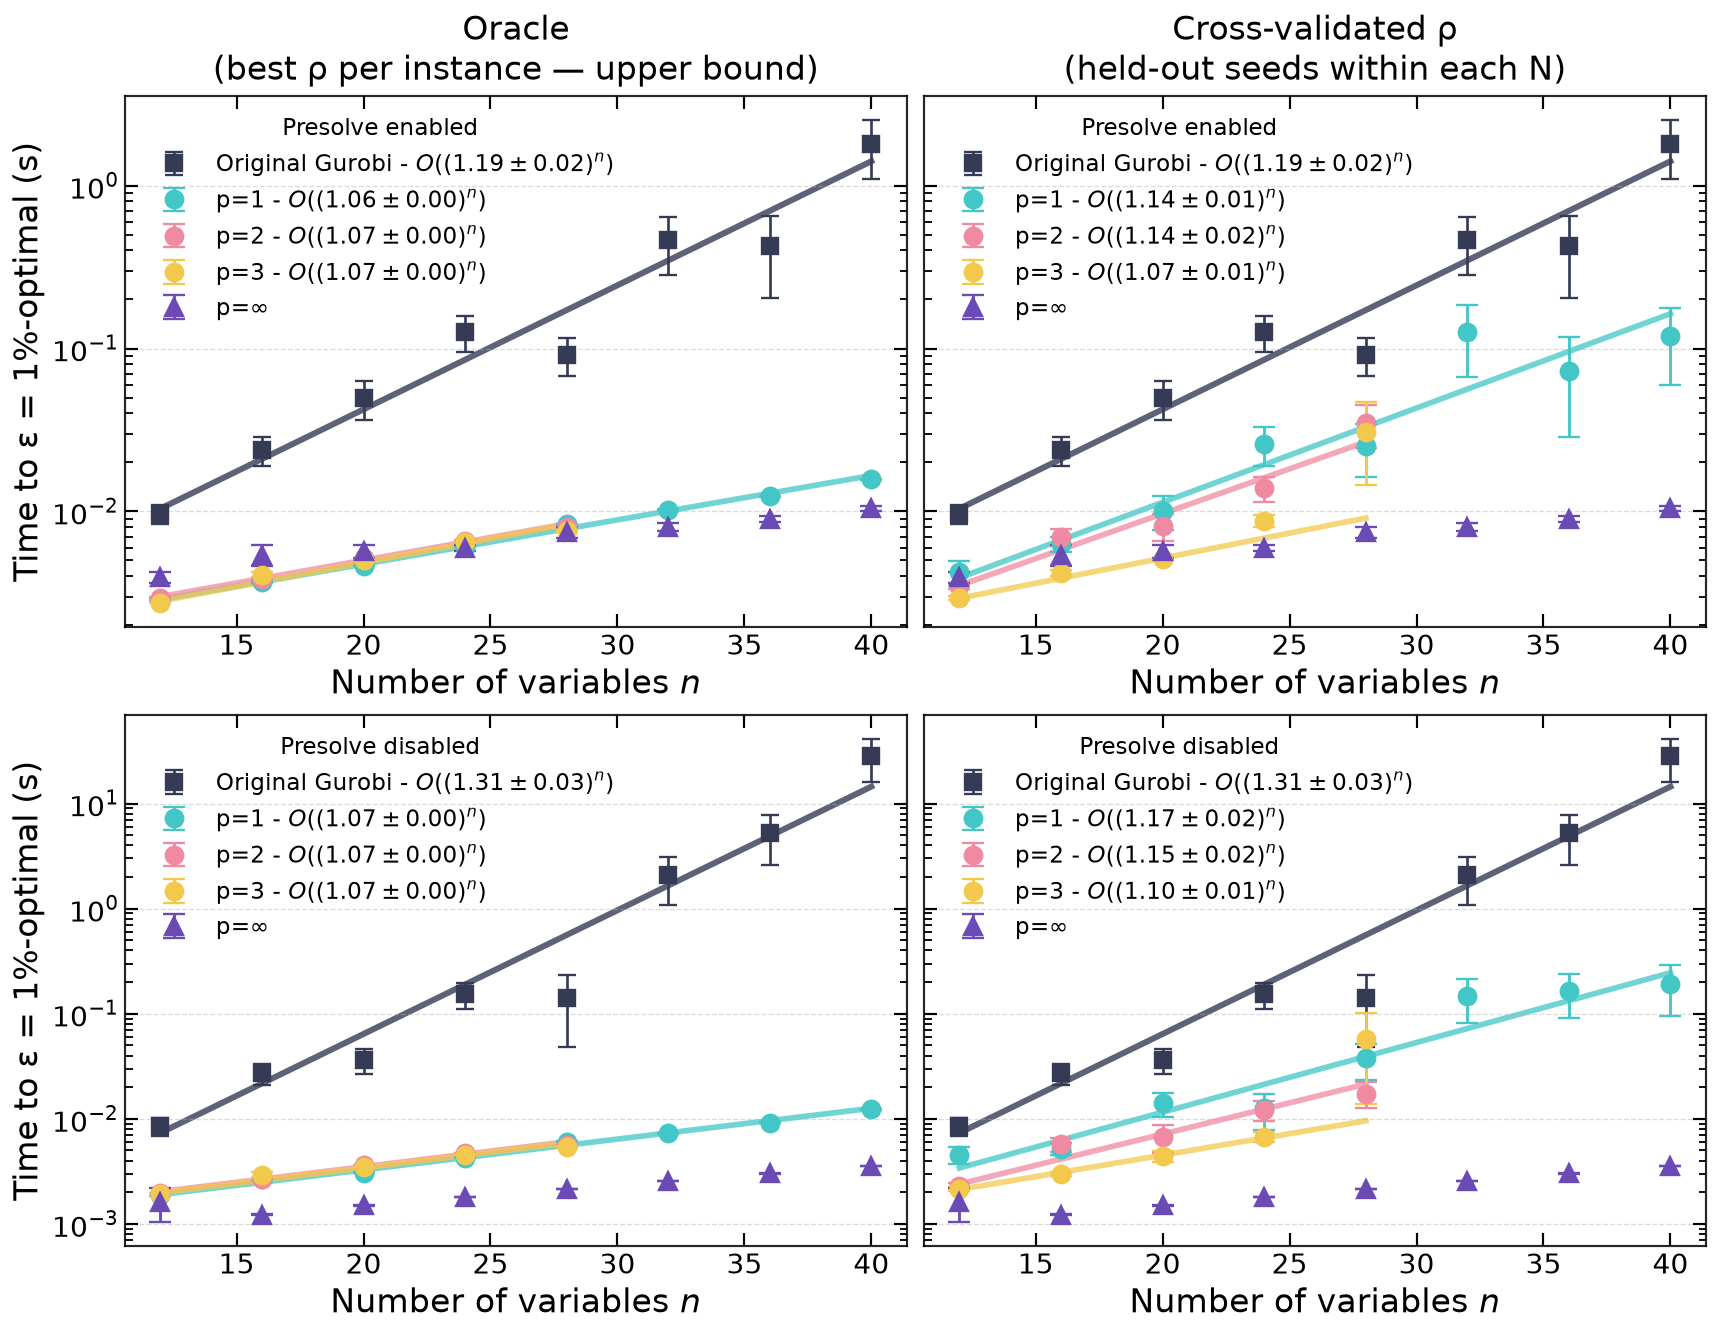

In [6]:
# Combined scaling grid: rows = presolve on/off, cols = oracle/cross-validated
# strategy, eps=1% only. Self-contained (loads its own on/off data) so it
# doesn't depend on whatever the global PRESOLVE toggle happens to be set to.
quantum_grid_on_df = load_family_comparison_data(
    problem_sizes=QUANTUM_SCALING_SIZES_ON,
    family="quantum",
    param_values=QUANTUM_LAYERS,
    presolve=True,
    results_dir=RESULTS_DIR,
)
quantum_grid_on_traj_df = load_family_comparison_trajectory_data(
    problem_sizes=QUANTUM_SCALING_SIZES_ON,
    family="quantum",
    param_values=QUANTUM_COMPARE_PARAMS,
    presolve=True,
    results_dir=RESULTS_DIR,
)
quantum_grid_off_df = load_family_comparison_data(
    problem_sizes=QUANTUM_SCALING_SIZES_OFF,
    family="quantum",
    param_values=QUANTUM_LAYERS,
    presolve=False,
    results_dir=RESULTS_DIR,
)
quantum_grid_off_traj_df = load_family_comparison_trajectory_data(
    problem_sizes=QUANTUM_SCALING_SIZES_OFF,
    family="quantum",
    param_values=QUANTUM_COMPARE_PARAMS,
    presolve=False,
    results_dir=RESULTS_DIR,
)

if INCLUDE_P_INF:
    quantum_grid_on_inf_df = load_quantum_infinite_depth_comparison_data(
        problem_sizes=QUANTUM_SCALING_SIZES_ON,
        presolve=True,
        results_dir=RESULTS_DIR,
        data_root=REPO_ROOT / "one_equality_new" / "complete_random",
    )
    quantum_grid_off_inf_df = load_quantum_infinite_depth_comparison_data(
        problem_sizes=QUANTUM_SCALING_SIZES_OFF,
        presolve=False,
        results_dir=RESULTS_DIR,
        data_root=REPO_ROOT / "one_equality_new" / "complete_random",
    )
    quantum_grid_on_df = pd.concat([quantum_grid_on_df, quantum_grid_on_inf_df], ignore_index=True)
    quantum_grid_off_df = pd.concat([quantum_grid_off_df, quantum_grid_off_inf_df], ignore_index=True)

quantum_grid_combined_df = pd.concat([quantum_grid_on_df, quantum_grid_off_df], ignore_index=True)
quantum_grid_combined_traj_df = pd.concat([quantum_grid_on_traj_df, quantum_grid_off_traj_df], ignore_index=True)

fig_grid = plot_layer_comparison_grid_by_presolve(
    summary_df=quantum_grid_combined_df,
    layers_list=QUANTUM_COMPARE_PARAMS,
    traj_df=quantum_grid_combined_traj_df,
    eps_threshold=EPS_THRESHOLD,
    y_log=True,
)
plt.savefig(REPO_ROOT / "scaling_penalty_strategies.png", dpi=150, bbox_inches="tight")
plt.show()

## Performance Distribution

For each QAOA depth p and problem size N, this takes **each seed's own
best-performing ρ** (out of every ρ tested for that seed — an oracle-style,
per-seed selection, not a single shared ρ) and plots that seed's final
solution quality: `performance % = 100 × (1 − (final_baseline_obj − true_opt) / |true_opt|)`,
where 100% means the preconditioned solve matched the classical optimum
exactly. The top strip shows the fraction of instances landing at exactly
100% per N (headline number above each column); the log-scale main panel
shows the density-colored spread of whatever didn't quite reach 100%, with a
black bar for the mean. Because this cherry-picks each seed's best ρ, don't
expect it to line up with the scaling plots above (which mostly evaluate one
shared ρ across every seed) — a seed that looks great here can still miss the
threshold badly at the one ρ a shared-ρ strategy happens to pick.


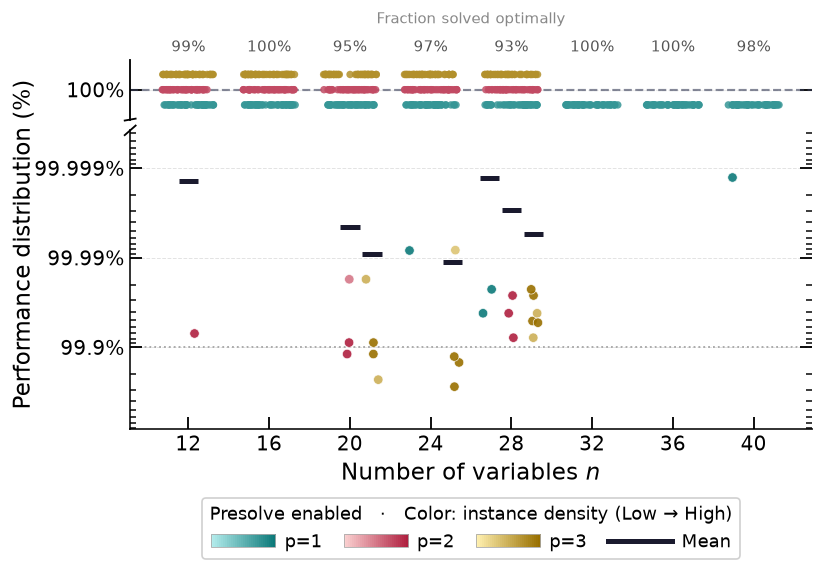

In [7]:
# Build per-p DataFrames for the performance distribution plot
perf_dfs = {}
for _p in QUANTUM_LAYERS:
    _frames = []
    for _n in QUANTUM_SCALING_SIZES:
        _fname = RESULTS_DIR / f"N={_n}_layers={_p}_presolve_{'on' if PRESOLVE else 'off'}.csv"
        try:
            _frames.append(pd.read_csv(_fname))
        except FileNotFoundError:
            pass
    if _frames:
        perf_dfs[f"p={_p}"] = pd.concat(_frames, ignore_index=True)

fig_perf = plot_performance_distribution(perf_dfs, presolve=PRESOLVE)
plt.show()